# Plannotate BLAST Scorer Analysis

This notebook evaluates the **PlannotateScorer** — a BLAST-based scorer that uses the
[plannotate](https://github.com/mmcguffi/pLannotate) feature database to score generated
plasmid sequences.

The analysis follows the same pattern as `pretrained_analysis.ipynb`:
1. Build the scorer from the plannotate parquet database
2. Validate on real plasmids from the training set
3. Apply controlled corruption at varying rates
4. Compare real vs corrupted vs random DNA baselines

In [7]:
import sys
import os
import time

# Ensure project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import re
from collections import defaultdict

## 1. Load Data

In [8]:
plannotate_db = pd.read_parquet(os.path.join(PROJECT_ROOT, "data", "plannotate_db.parquet"))
motif_registry = pd.read_parquet(os.path.join(PROJECT_ROOT, "data", "motif_registry_combined.parquet"))
training_pairs = pd.read_parquet(os.path.join(PROJECT_ROOT, "data", "training_pairs_v4.parquet"))

print(f"Plannotate DB: {plannotate_db.shape[0]:,} sequences")
print(f"Motif registry: {motif_registry.shape[0]:,} entries, {motif_registry['token'].nunique()} unique tokens")
print(f"Training pairs: {training_pairs.shape[0]:,} plasmids")
print()
print("Plannotate DB columns:", plannotate_db.columns.tolist())
plannotate_db.head(3)

Plannotate DB: 567,340 sequences
Motif registry: 660 entries, 57 unique tokens
Training pairs: 108,468 plasmids

Plannotate DB columns: ['uuid', 'category', 'features', 'plasmid_count', 'sseqid', 'db_source', 'seq_type', 'seq_len', 'sequence']


,uuid,category,features,plasmid_count,sseqid,db_source,seq_type,seq_len,sequence
0,7cab941c-224b-4bf5-8583-b624cffbf0b6,CDS,Dronpa-Green3,None,Dronpa_Green3,snapgene,nucleotide,678,ATGGTGAGTGTGATTAAACCAGACATGAAGATCAAGCTGCGTATGG...
1,ac7394a6-c785-47f2-b7fd-65b89a6112a0,CDS,CmR,None,CmR_(2),snapgene,nucleotide,660,ATGGAGAAAAAAATCACTGGATATACCACCGTTGATATATCCCAAT...
2,e86f077c-da76-44c6-9e71-9960e1cdd640,misc_feature,pRi replicator region,None,pRi_replicator_region,snapgene,nucleotide,4636,GATCCTACAAGGTAGAATCCGCCTGAGTCGCAAGGGTGACTTCGCC...


## 2. Initialize the PlannotateScorer

This builds local BLAST databases (nucleotide + protein) from the plannotate parquet
and uses the **motif registry** as a bridge to map annotation tokens (e.g. `<AMR_AMPICILLIN>`)
to plannotate sseqids (e.g. `AmpR`). Without this bridge, naive substring matching fails
because tokens use drug/feature names while plannotate uses gene names.

In [9]:
from post_training.scorers.plannotate import PlannotateScorer

db_dir = os.path.join(PROJECT_ROOT, "data", "plannotate_blast_db")

t0 = time.time()
scorer = PlannotateScorer(
    plannotate_df=plannotate_db,
    motif_registry_df=motif_registry,
    db_dir=db_dir,
    evalue=1e-5,
)
t_init = time.time() - t0

print(f"Scorer initialized in {t_init:.1f}s")
print(f"Filtered DB: {len(scorer.plannotate_df):,} sequences (from {len(plannotate_db):,})")
print(f"Nucleotide DB: {scorer._nucl_db}")
print(f"Protein DB: {scorer._prot_db}")
print(f"Token bridge: {len(scorer._token_bridge)} tokens mapped")

for tok, sids in list(scorer._token_bridge.items())[:5]:
    print(f"  {tok} -> {sids[:3]}{'...' if len(sids) > 3 else ''}")

Scorer initialized in 1.3s
Filtered DB: 611 sequences (from 567,340)
Nucleotide DB: /Users/mcclainthiel/Projects/PhD/PlasmidLLM/data/plannotate_blast_db/plannotate_nucl
Protein DB: /Users/mcclainthiel/Projects/PhD/PlasmidLLM/data/plannotate_blast_db/plannotate_prot
Token bridge: 57 tokens mapped
  <AMR_AMPICILLIN> -> ['AmpR', 'AmpR_(2)', 'AmpR_(3)']...
  <AMR_BLASTICIDIN> -> ['BSD', 'P0C2P0', 'P33967']...
  <AMR_CHLORAMPHENICOL> -> ['CmR', 'CmR_(2)', 'CmR_(3)']...
  <AMR_GENTAMICIN> -> ['GmR', 'P23181', 'ApmR']...
  <AMR_HYGROMYCIN> -> ['HygR', 'HygR_(2)', 'HygR_(3)']...


## 3. Corruption Function

Same controlled mutation function from `pretrained_analysis.ipynb`.

In [10]:
def corrupt_plasmid(seq, n_sub=0, n_ins=0, n_del=0, max_ins_len=15, seed=None):
    """Apply controlled mutations to a DNA sequence."""
    if seed is not None:
        random.seed(seed)
    bases = list(seq.replace('\n', '').replace(' ', ''))

    for _ in range(n_sub):
        pos = random.randint(0, len(bases) - 1)
        bases[pos] = random.choice([b for b in "ATGC" if b != bases[pos]])

    for _ in range(n_del):
        if len(bases) > 100:
            pos = random.randint(0, len(bases) - 1)
            bases.pop(pos)

    for _ in range(n_ins):
        pos = random.randint(0, len(bases))
        insert = ''.join(random.choice("ATGC") for _ in range(random.randint(1, max_ins_len)))
        bases[pos:pos] = list(insert)

    return ''.join(bases)

## 4. Sample Real Plasmids

We sample plasmids from the training set and score them.

In [11]:
HARD_PREFIXES = {"AMR_", "ORI_", "PROM_", "REPORTER_", "REP_", "TAG_", "ELEM_"}

sample = training_pairs[training_pairs.sequence.str.len() > 500].sample(30, random_state=42)
print(f"Sampled {len(sample)} plasmids for analysis")
sample[['plasmid_id', 'prompt', 'sequence_length']].head()

Sampled 30 plasmids for analysis


,plasmid_id,prompt,sequence_length
28945,131603,<BOS><VEC_MAMMALIAN><VEC_RETROVIRAL><SP_MOUSE>...,5632
73876,128813,<BOS><VEC_LENTIVIRAL><SP_RAT><AMR_AMPICILLIN><...,10906
43992,105635,<BOS><VEC_BACTERIAL><SP_HUMAN><SP_MOUSE><COPY_...,5497
42508,123654,<BOS><COPY_HIGH><AMR_KANAMYCIN><ORI_COLE1><PRO...,2866
66683,154255,<BOS><VEC_MAMMALIAN><AMR_AMPICILLIN><ORI_COLE1...,4809


## 5. Score Real vs Corrupted vs Random

For each plasmid we compute:
- **Real**: score on the original sequence
- **Mild corruption**: 5% substitution rate
- **Heavy corruption**: 20% substitution rate
- **Random DNA**: length-matched random sequence

In [12]:
def score_row(row, seq_override=None, corrupt_fn=None):
    """Score a single row using the PlannotateScorer."""
    prompt = row.prompt

    if seq_override is not None:
        seq = seq_override
    elif corrupt_fn is not None:
        seq = corrupt_fn(row.sequence)
    else:
        seq = row.sequence

    result = scorer.score_sequence_detailed(prompt, seq, sharpness=2.0)
    return result["composite"]


def generate_random_dna(length, seed=None):
    if seed is not None:
        random.seed(seed)
    return ''.join(random.choice('ATGC') for _ in range(length))


print("Scoring real plasmids...")
real_scores = sample.apply(score_row, axis=1).dropna()

print("Scoring mild corruption (5% sub)...")
mild_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
        s,
        n_sub=int(len(s) * 0.05),
        n_ins=int(len(s) * 0.01),
        n_del=int(len(s) * 0.01),
    )),
    axis=1
).dropna()

print("Scoring heavy corruption (20% sub)...")
broken_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
        s,
        n_sub=int(len(s) * 0.20),
        n_ins=int(len(s) * 0.05),
        n_del=int(len(s) * 0.05),
    )),
    axis=1
).dropna()

print("Scoring random DNA baseline...")
random_scores = sample.apply(
    lambda r: score_row(r, seq_override=generate_random_dna(len(r.sequence), seed=42)),
    axis=1
).dropna()

print("Done!")

Scoring real plasmids...
Scoring mild corruption (5% sub)...
Scoring heavy corruption (20% sub)...
Scoring random DNA baseline...
Done!


## 6. Results

In [13]:
print(f"{'Condition':<30s} {'Mean':>6s} {'Median':>7s} {'Std':>6s} {'Min':>6s} {'Max':>6s}")
print("-" * 65)
for name, s in [
    ("Real plasmids", real_scores),
    ("Mild corruption (5%)", mild_scores),
    ("Heavy corruption (20%)", broken_scores),
    ("Random DNA", random_scores),
]:
    print(f"{name:<30s} {s.mean():6.3f} {s.median():7.3f} {s.std():6.3f} {s.min():6.3f} {s.max():6.3f}")

Condition                        Mean  Median    Std    Min    Max
-----------------------------------------------------------------
Real plasmids                   0.602   0.615  0.057  0.448  0.680
Mild corruption (5%)            0.479   0.507  0.073  0.299  0.571
Heavy corruption (20%)          0.162   0.166  0.032  0.094  0.252
Random DNA                      0.042   0.000  0.056  0.000  0.205


## 7. Visualize Score Distributions

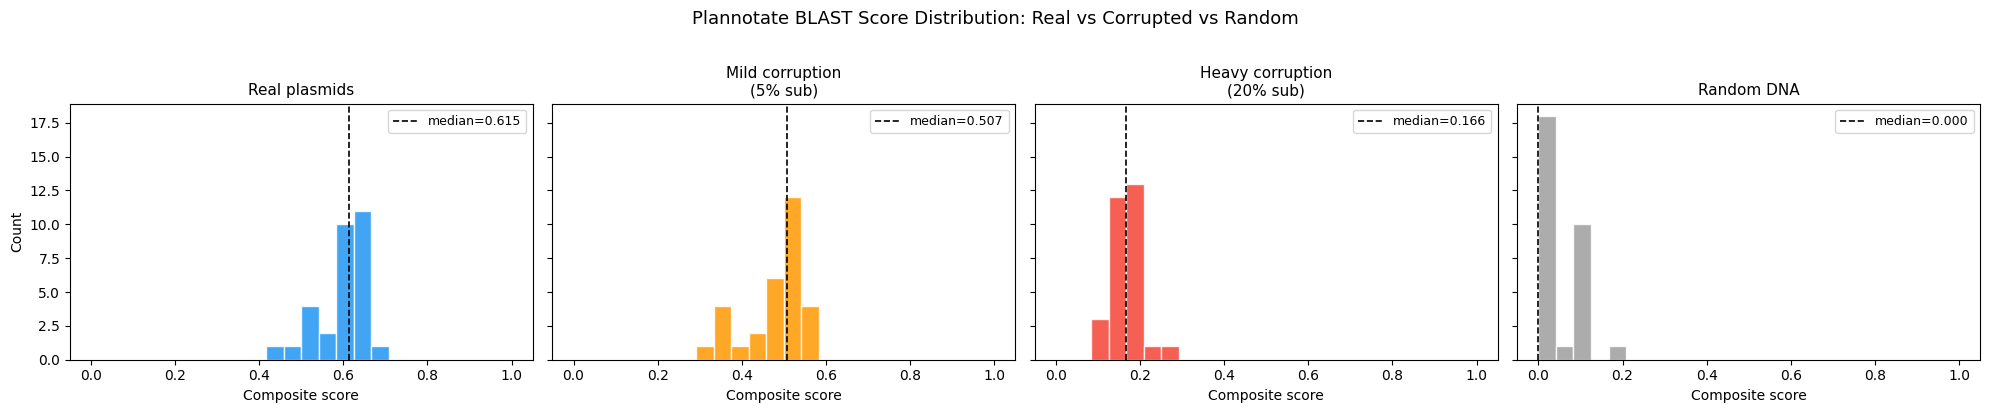

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True, sharex=True)
bins = np.linspace(0, 1, 25)

conditions = [
    ("Real plasmids", real_scores, "#2196F3"),
    ("Mild corruption\n(5% sub)", mild_scores, "#FF9800"),
    ("Heavy corruption\n(20% sub)", broken_scores, "#F44336"),
    ("Random DNA", random_scores, "#9E9E9E"),
]

for ax, (title, scores, color) in zip(axes, conditions):
    ax.hist(scores, bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(scores.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"median={scores.median():.3f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Composite score")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Plannotate BLAST Score Distribution: Real vs Corrupted vs Random",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Paired Score Drops

For each plasmid, the delta between its real score and its corrupted score.

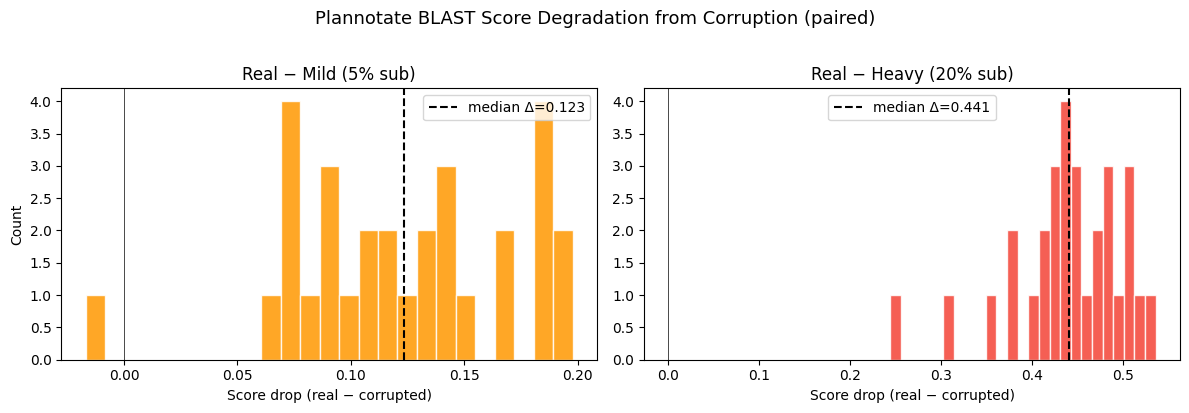

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

delta_mild = real_scores.values - mild_scores.values
delta_broken = real_scores.values - broken_scores.values

for ax, delta, title, color in zip(
    axes,
    [delta_mild, delta_broken],
    ["Real \u2212 Mild (5% sub)", "Real \u2212 Heavy (20% sub)"],
    ["#FF9800", "#F44336"],
):
    ax.hist(delta, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linestyle="-", linewidth=0.5)
    ax.axvline(np.median(delta), color="black", linestyle="--",
               label=f"median \u0394={np.median(delta):.3f}")
    ax.set_xlabel("Score drop (real \u2212 corrupted)")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Plannotate BLAST Score Degradation from Corruption (paired)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Combined Comparison

Side-by-side comparison of all conditions.

/var/folders/dx/4txl5y6x6wl03w9qh_zrgvj80000gn/T/ipykernel_77262/2768543151.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.5)


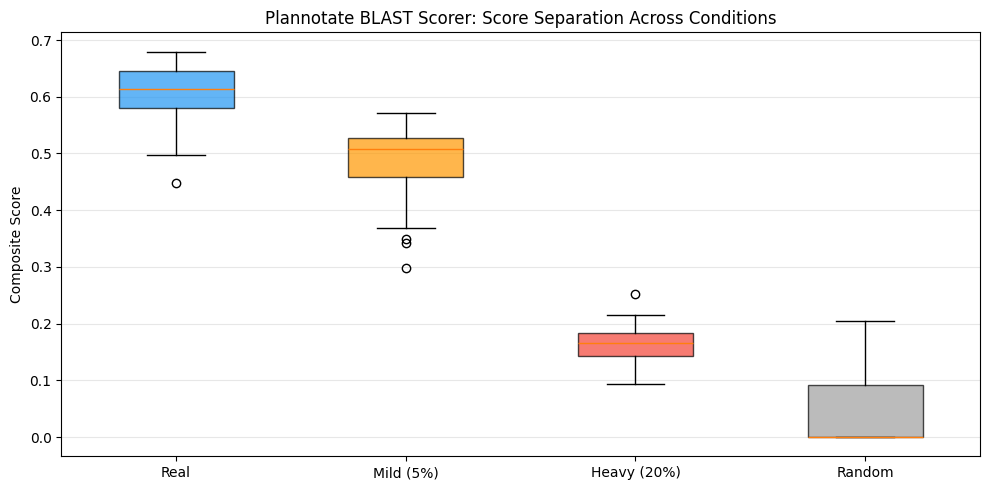

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

data_to_plot = [real_scores, mild_scores, broken_scores, random_scores]
labels = ["Real", "Mild (5%)", "Heavy (20%)", "Random"]
colors = ["#2196F3", "#FF9800", "#F44336", "#9E9E9E"]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Composite Score")
ax.set_title("Plannotate BLAST Scorer: Score Separation Across Conditions")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Corruption Sweep

Sweep across increasing corruption rates to visualize how the score degrades.

In [17]:
corruption_rates = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
sweep_sample = sample.head(10)

rate_to_scores = {}

for rate in corruption_rates:
    print(f"Scoring at {rate*100:.0f}% corruption rate...")
    if rate == 0:
        scores = sweep_sample.apply(score_row, axis=1).dropna()
    else:
        scores = sweep_sample.apply(
            lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
                s,
                n_sub=int(len(s) * rate),
                n_ins=int(len(s) * rate * 0.2),
                n_del=int(len(s) * rate * 0.2),
            )),
            axis=1
        ).dropna()
    rate_to_scores[rate] = scores

print("Done!")

Scoring at 0% corruption rate...
Scoring at 1% corruption rate...
Scoring at 2% corruption rate...
Scoring at 5% corruption rate...
Scoring at 10% corruption rate...
Scoring at 20% corruption rate...
Scoring at 30% corruption rate...
Scoring at 50% corruption rate...
Done!


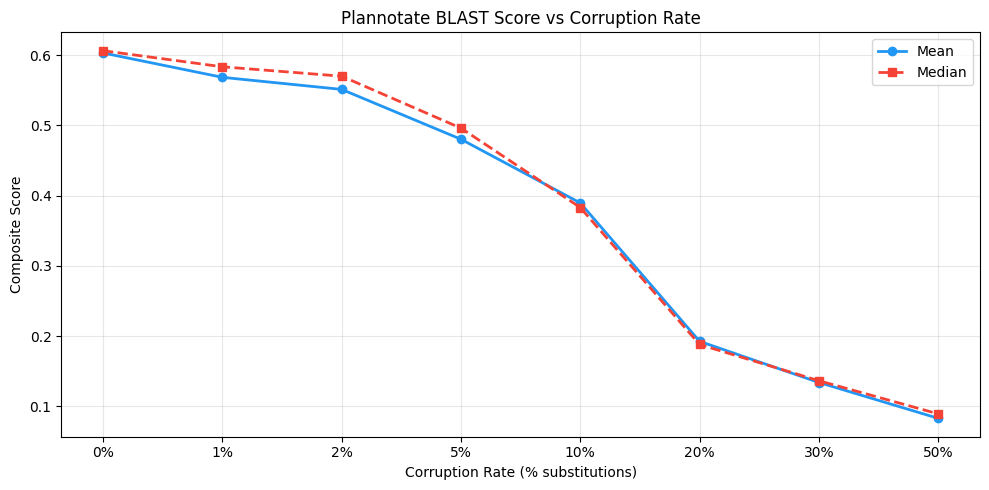

Rate           Mean   Median
------------------------------
    0%       0.6033   0.6065
    1%       0.5685   0.5836
    2%       0.5513   0.5701
    5%       0.4803   0.4961
   10%       0.3895   0.3831
   20%       0.1924   0.1879
   30%       0.1338   0.1362
   50%       0.0827   0.0890


In [18]:
means = [rate_to_scores[r].mean() for r in corruption_rates]
medians = [rate_to_scores[r].median() for r in corruption_rates]
pct_labels = [f"{r*100:.0f}%" for r in corruption_rates]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pct_labels, means, 'o-', label='Mean', color='#2196F3', linewidth=2)
ax.plot(pct_labels, medians, 's--', label='Median', color='#F44336', linewidth=2)
ax.set_xlabel('Corruption Rate (% substitutions)')
ax.set_ylabel('Composite Score')
ax.set_title('Plannotate BLAST Score vs Corruption Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Rate':<10s} {'Mean':>8s} {'Median':>8s}")
print("-" * 30)
for r, m, md in zip(corruption_rates, means, medians):
    print(f"{r*100:>5.0f}%     {m:8.4f} {md:8.4f}")

## 11. Diagnostic: Why Real Plasmids Don't Score ~1.0

The composite scoring formula has **three multiplicative factors**:

1. **Per-token quality** = `w_id * (pct_id/100) + w_cov * (coverage/100) + w_norm * min(norm_score/norm_score_cap, 1.0)`
   - Defaults: `w_id=0.4, w_cov=0.35, w_norm=0.25, norm_score_cap=5.0`
2. **Overall quality** = `geo_mean(token_scores) ^ sharpness` (sharpness=2.0)
3. **Recall penalty** = `recall_floor + (1 - recall_floor) * recall` (recall_floor=0.5)
4. **composite** = quality × recall_penalty

The **key problem** is `norm_score_cap = 5.0`. For nucleotide BLAST, a *perfect* match yields
`bitscore/slen ≈ 1.7–1.8`, so even a perfect hit gets `norm_scaled ≈ 0.35`. This caps the
per-token quality at ~0.84 and after squaring (sharpness=2), the theoretical maximum is **~0.70**.

This matches the observed max of **0.680** for real plasmids.

Below we run detailed diagnostics to verify this and show every component.

In [23]:
# ── Run score_sequence_detailed on every real plasmid ────────────────────
NORM_SCORE_CAP = 5.0  # current default

diag_rows = []
for _, row in sample.iterrows():
    result = scorer.score_sequence_detailed(row.prompt, row.sequence, sharpness=2.0)
    if not result["token_scores"]:
        continue
    diag_rows.append(result)

print(f"Diagnosed {len(diag_rows)} real plasmids\n")

# ── Aggregate per-token component distributions ─────────────────────────
all_id, all_cov, all_norm_scaled, all_norm_raw, all_tq = [], [], [], [], []
for d in diag_rows:
    for tok, info in d["token_scores"].items():
        if not info["found"]:
            continue
        id_score    = info["pct_id"] / 100.0
        cov_score   = info["coverage"] / 100.0
        norm_raw    = info["norm_score"]
        norm_scaled = min(norm_raw / NORM_SCORE_CAP, 1.0)
        tok_quality = 0.4 * id_score + 0.35 * cov_score + 0.25 * norm_scaled

        all_id.append(id_score)
        all_cov.append(cov_score)
        all_norm_raw.append(norm_raw)
        all_norm_scaled.append(norm_scaled)
        all_tq.append(tok_quality)

print("=== Per-token component distributions (all real plasmids) ===")
for name, arr in [("id_score", all_id), ("cov_score", all_cov),
                  ("norm_scaled", all_norm_scaled), ("tok_quality", all_tq)]:
    a = np.array(arr)
    print(f"  {name:14s}  mean={a.mean():.4f}  median={np.median(a):.4f}  "
          f"min={a.min():.4f}  max={a.max():.4f}")

composites = [d["composite"] for d in diag_rows]
recalls    = [d["recall"] for d in diag_rows]
qualities  = [d["quality"] for d in diag_rows]
print(f"\n=== Composite breakdown (n={len(diag_rows)}) ===")
for name, arr in [("quality", qualities), ("recall", recalls), ("composite", composites)]:
    a = np.array(arr)
    print(f"  {name:12s}  mean={a.mean():.4f}  median={np.median(a):.4f}  "
          f"min={a.min():.4f}  max={a.max():.4f}")

# ── Worst-scoring real plasmid breakdown ─────────────────────────────────
worst_idx = int(np.argmin(composites))
worst = diag_rows[worst_idx]
print(f"\n=== Worst-scoring real plasmid (composite={worst['composite']:.4f}) ===")
print(f"    expected={worst['expected']}, found={worst['found']}, "
      f"recall={worst['recall']:.3f}, recall_penalty={worst['recall_penalty']:.3f}")
print(f"    geo_mean={worst['geo_mean']:.4f}, quality={worst['quality']:.4f}")
for tok, info in worst["token_scores"].items():
    if info["found"]:
        ns = min(info["norm_score"] / NORM_SCORE_CAP, 1.0)
        print(f"    {tok:30s}  id={info['pct_id']/100:.3f}  cov={info['coverage']/100:.3f}  "
              f"norm_raw={info['norm_score']:.3f}  norm_scaled={ns:.3f}  "
              f"tok_q={info['score']:.4f}")
    else:
        print(f"    {tok:30s}  ** NOT FOUND **")

# ── Best-scoring real plasmid breakdown ──────────────────────────────────
best_idx = int(np.argmax(composites))
best_d = diag_rows[best_idx]
print(f"\n=== Best-scoring real plasmid (composite={best_d['composite']:.4f}) ===")
print(f"    expected={best_d['expected']}, found={best_d['found']}, "
      f"recall={best_d['recall']:.3f}, recall_penalty={best_d['recall_penalty']:.3f}")
print(f"    geo_mean={best_d['geo_mean']:.4f}, quality={best_d['quality']:.4f}")
for tok, info in best_d["token_scores"].items():
    if info["found"]:
        ns = min(info["norm_score"] / NORM_SCORE_CAP, 1.0)
        print(f"    {tok:30s}  id={info['pct_id']/100:.3f}  cov={info['coverage']/100:.3f}  "
              f"norm_raw={info['norm_score']:.3f}  norm_scaled={ns:.3f}  "
              f"tok_q={info['score']:.4f}")
    else:
        print(f"    {tok:30s}  ** NOT FOUND **")

Diagnosed 30 real plasmids

=== Per-token component distributions (all real plasmids) ===
  id_score        mean=0.9853  median=1.0000  min=0.2512  max=1.0000
  cov_score       mean=0.9633  median=1.0000  min=0.0388  max=1.0000
  norm_scaled     mean=0.3521  median=0.3694  min=0.0102  max=0.3832
  tok_quality     mean=0.8193  median=0.8416  min=0.3513  max=0.8453

=== Composite breakdown (n=30) ===
  quality       mean=0.6680  median=0.6875  min=0.4972  max=0.7111
  recall        mean=0.8054  median=0.8257  min=0.5000  max=1.0000
  composite     mean=0.6021  median=0.6145  min=0.4475  max=0.6797

=== Worst-scoring real plasmid (composite=0.4475) ===
    expected=5, found=4, recall=0.800, recall_penalty=0.900
    geo_mean=0.7052, quality=0.4972
    <AMR_AMPICILLIN>                id=1.000  cov=1.000  norm_raw=1.848  norm_scaled=0.370  tok_q=0.8424
    <ORI_COLE1>                     id=1.000  cov=1.000  norm_raw=1.847  norm_scaled=0.369  tok_q=0.8424
    <PROM_AMPR>                     

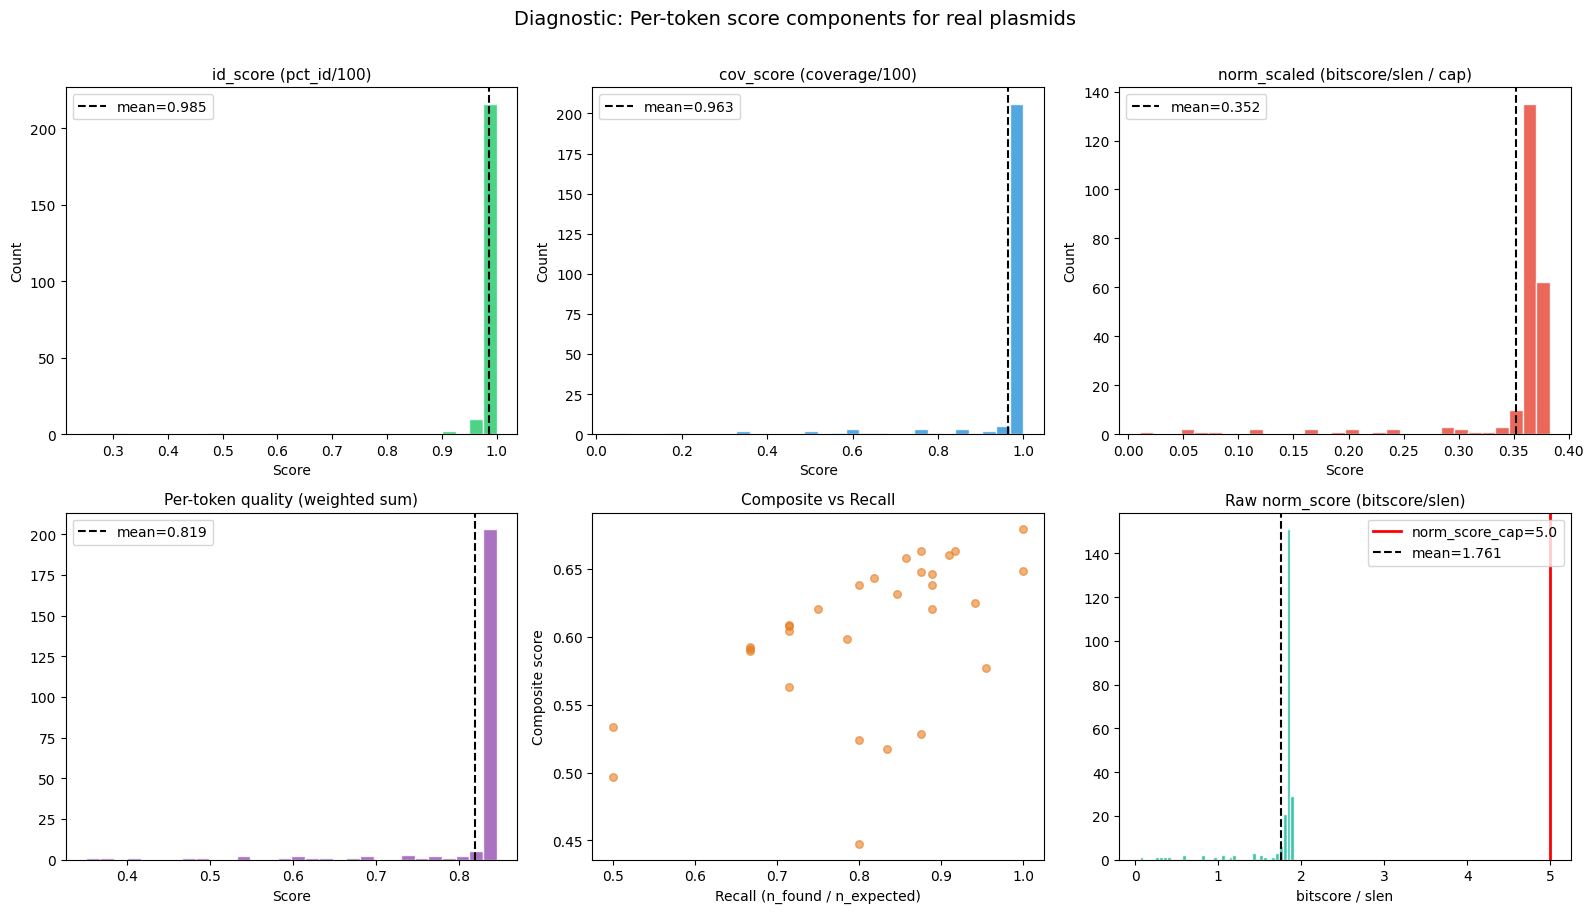

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: per-token component histograms
for ax, (name, arr, color) in zip(axes[0], [
    ("id_score (pct_id/100)",  all_id,   "#2ecc71"),
    ("cov_score (coverage/100)", all_cov, "#3498db"),
    ("norm_scaled (bitscore/slen / cap)", all_norm_scaled, "#e74c3c"),
]):
    ax.hist(arr, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(arr), color="black", ls="--", lw=1.5, label=f"mean={np.mean(arr):.3f}")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend()

# Row 2, col 0: per-token quality
axes[1][0].hist(all_tq, bins=30, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[1][0].axvline(np.mean(all_tq), color="black", ls="--", lw=1.5,
                   label=f"mean={np.mean(all_tq):.3f}")
axes[1][0].set_title("Per-token quality (weighted sum)", fontsize=11)
axes[1][0].set_xlabel("Score")
axes[1][0].legend()

# Row 2, col 1: composite vs recall
axes[1][1].scatter(recalls, composites, alpha=0.6, s=30, color="#e67e22")
axes[1][1].set_xlabel("Recall (n_found / n_expected)")
axes[1][1].set_ylabel("Composite score")
axes[1][1].set_title("Composite vs Recall", fontsize=11)

# Row 2, col 2: raw norm_score distribution showing the cap is too high
axes[1][2].hist(all_norm_raw, bins=40, color="#1abc9c", edgecolor="white", alpha=0.85)
axes[1][2].axvline(5.0, color="red", ls="-", lw=2, label="norm_score_cap=5.0")
axes[1][2].axvline(np.mean(all_norm_raw), color="black", ls="--", lw=1.5,
                   label=f"mean={np.mean(all_norm_raw):.3f}")
axes[1][2].set_title("Raw norm_score (bitscore/slen)", fontsize=11)
axes[1][2].set_xlabel("bitscore / slen")
axes[1][2].legend()

fig.suptitle("Diagnostic: Per-token score components for real plasmids", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

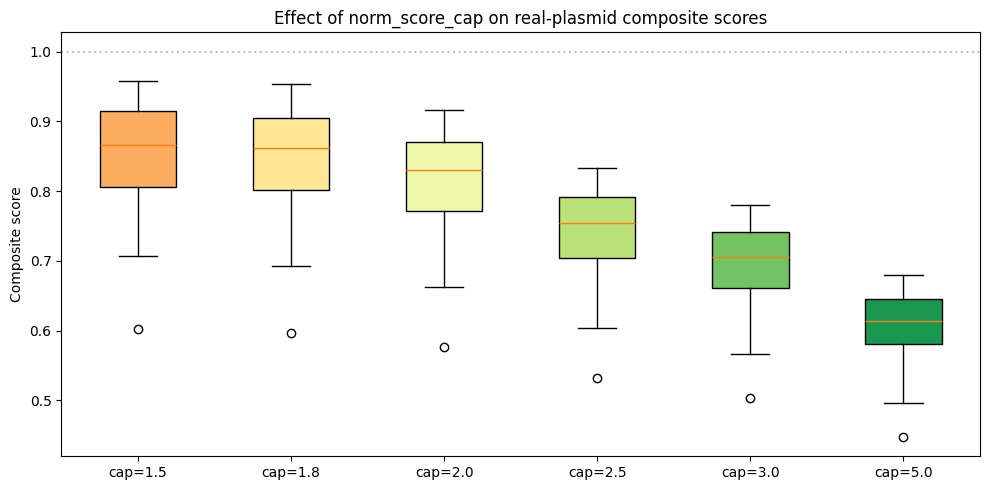


Summary by norm_score_cap:
  cap= 1.5  mean=0.8475  median=0.8657  min=0.6017  max=0.9580
  cap= 1.8  mean=0.8417  median=0.8620  min=0.5963  max=0.9537
  cap= 2.0  mean=0.8103  median=0.8297  min=0.5771  max=0.9162
  cap= 2.5  mean=0.7375  median=0.7544  min=0.5323  max=0.8335
  cap= 3.0  mean=0.6908  median=0.7062  min=0.5033  max=0.7805
  cap= 5.0  mean=0.6021  median=0.6145  min=0.4475  max=0.6797


In [25]:
# ── Sensitivity: What if we lower norm_score_cap? ────────────────────────
# Re-score all real plasmids with different norm_score_cap values.
# score_sequence_detailed accepts norm_score_cap, so we just call it again.

cap_values = [1.5, 1.8, 2.0, 2.5, 3.0, 5.0]
cap_composites = {c: [] for c in cap_values}

for _, row in sample.iterrows():
    for cap in cap_values:
        result = scorer.score_sequence_detailed(
            row.prompt, row.sequence, sharpness=2.0, norm_score_cap=cap,
        )
        cap_composites[cap].append(result["composite"])

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(cap_values))
bp_data = [cap_composites[c] for c in cap_values]
bp = ax.boxplot(bp_data, positions=positions, widths=0.5, patch_artist=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cap_values)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_xticks(positions)
ax.set_xticklabels([f"cap={c}" for c in cap_values])
ax.set_ylabel("Composite score")
ax.set_title("Effect of norm_score_cap on real-plasmid composite scores")
ax.axhline(1.0, color="gray", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nSummary by norm_score_cap:")
for c in cap_values:
    a = np.array(cap_composites[c])
    print(f"  cap={c:4.1f}  mean={a.mean():.4f}  median={np.median(a):.4f}  "
          f"min={a.min():.4f}  max={a.max():.4f}")